# Single-Stock Return Analysis - Meta Platforms (2012-2026)

**Question:** What do the return, volatility, and drawdown characteristics of a single large-cap equity look like - and how far do they depart from the normal distribution assumed by introductory models? 

**Data:** Yahoo Finance daily prices via 'yfinance' ('auto_adjust=True', so splits and dividends are folded in - daily percent change approximates a total return).
Downloaded once and cached to 'data/'; the analysis reads from disk.

**Author:** Alexandre • [Github](https://github.com/alexandret-11) • [LinkedIn](https://linkedin.com/in/alexandrethompson)

---
*Project 1 of a 7-project quantitative research portfolio. Next: multi-asset comparison and correlation structure*

## Setup

Interim data source while WRDS/CRSP access is pending. The pull is isolated in a single cell so that the data layer can be swapped for CRSP later without touching any analysis code.

## Data

One network call, then cached. Two data-handling details worth flagging: newer 'yfinance' versions return two-level columns (flattened at the boundary below), and the first row's return is 'NaN by construction - a series of *n* prices yields *n-1* returns.

In [1]:
# Block 0 - Data Pull(Yahoo Finance)
# Interim source while WRDS summer access is pending

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# auto_adjust=True -> closes adjusted for splits AND dividends, so pct_change
# approximates a total return
raw = yf.download(
    "META",
    start="2012-05-18",  # IPO date
    auto_adjust=True,
    progress=False,
)

# Newer yfinance returns MultiIndex columns (built for multi-ticker calls);
# flatten so raw["Close"] works across versions
if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = raw.columns.get_level_values(0)

# .copy() serves df from raw -> avoids SettingWithCopyWarning on assignment
df = raw[["Close"]].rename(columns={"Close": "px_adj"}).copy()
df["ret"] = df["px_adj"].pct_change()
df.to_csv("../data/meta_prices_yf.csv")

# Four Diagnostic Tests
print(df.shape)
print(df.head(3))
print(df.tail(3))
print(df["ret"].isna().sum())

(3590, 2)
Price          px_adj       ret
Date                           
2012-05-18  37.897202       NaN
2012-05-21  33.733765 -0.109861
2012-05-22  30.730139 -0.089039
Price           px_adj       ret
Date                            
2026-08-26  576.140015  0.010683
2026-08-27  571.099976 -0.008748
2026-08-28  578.020020  0.012117
1


In [2]:
df["log"] = np.log(df["px_adj"]).diff()

print(df[["ret", "log"]].describe())

gap = (df["ret"] - df["log"]).abs()
print(df.loc[gap.nlargest(5).index, ["ret", "log"]])

print(
    f"Worst day: {df['ret'].idxmin().date()} "
    f"simple {df['ret'].min():.2%}, "
    f"log {df['log'].min():.2%}"
)

Price          ret          log
count  3589.000000  3589.000000
mean      0.001074     0.000759
std       0.025106     0.025109
min      -0.263901    -0.306391
25%      -0.010188    -0.010240
50%       0.000966     0.000965
75%       0.012691     0.012611
max       0.296114     0.259371
Price            ret       log
Date                          
2022-02-03 -0.263901 -0.306391
2013-07-25  0.296114  0.259371
2022-10-27 -0.245571 -0.281794
2023-02-02  0.232824  0.209307
2018-07-26 -0.189609 -0.210239
Worst day: 2022-02-03 simple -26.39%, log -30.64%


### Figure 1: The Price Path 

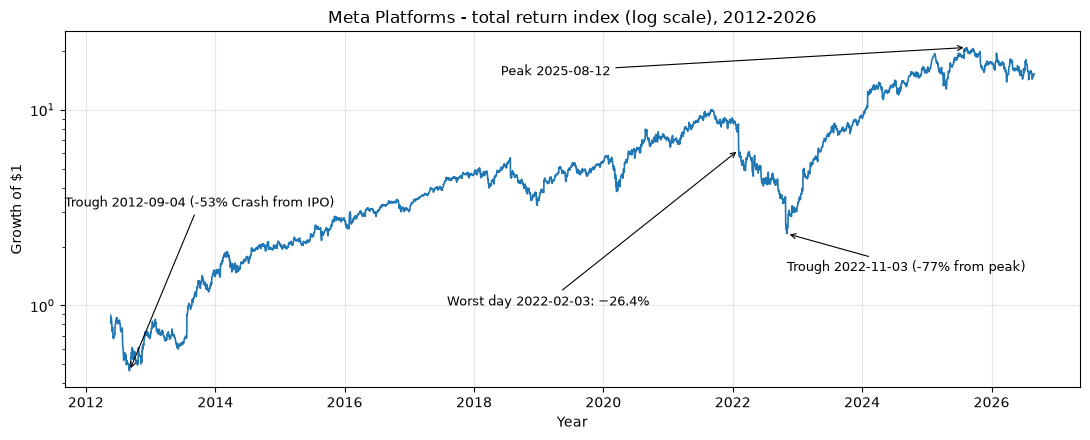

In [3]:
r = df["ret"].dropna()
tri = (1 + r).cumprod()  # total return index, starts at ~1

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(tri.index, tri.values, lw=1.2)
ax.set_yscale("log")
ax.set_title("Meta Platforms - total return index (log scale), 2012-2026")
ax.set_xlabel("Year")
ax.set_ylabel("Growth of $1")
ax.grid(alpha=0.3)
plt.tight_layout()

# --- annotations: peak, trough, worst single day ---
peak_dt = tri.loc["2012":"2026"].idxmax()
trough1_dt = tri.loc["2012":"2026"].idxmin()
trough2_dt = tri.loc["2022":"2026"].idxmin()
crash_dt = pd.Timestamp("2012-02-03")

ax.annotate(
    f"Peak {peak_dt.date()}",
    xy=(peak_dt, tri[peak_dt]),
    xytext=(pd.Timestamp("2018-06-01"), 15),
    arrowprops=dict(arrowstyle="->", lw=0.8),
    fontsize=9,
)

ax.annotate(
    f"Trough {trough1_dt.date()} (-53% Crash from IPO)",
    xy=(trough1_dt, tri[trough1_dt]),
    xytext=(pd.Timestamp("2011-09-04"), 3.2),
    arrowprops=dict(arrowstyle="->", lw=0.8),
    fontsize=9,
)

ax.annotate(
    f"Trough {trough2_dt.date()} (-77% from peak)",
    xy=(trough2_dt, tri[trough2_dt]),
    xytext=(pd.Timestamp("2022-11-03"), 1.5),
    arrowprops=dict(arrowstyle="->", lw=0.8),
    fontsize=9,
)

crash_dt = df["ret"].idxmin()

ax.annotate(
    f"Worst day {crash_dt.date()}: −{abs(df['ret'].min()):.1%}",
    xy=(crash_dt, tri[crash_dt]),
    xytext=(pd.Timestamp("2017-08-01"), 1),
    arrowprops=dict(arrowstyle="->", lw=0.8),
    fontsize=9,
)

fig.savefig("../output/fig1_total_return_index.png", dpi=150, bbox_inches="tight")


### The Story Behind the Price

1. **The IPO crash (May-September 2012).** Meta's first months as a public company were a disaster: from the $38 IPO price, the stock fell roughly 53% to its September 2012 bottom, weighed down by a botched NASDAQ opening and doubts about mobile advertising revenue. The chart opens with a crisis.

2. **The long climb (2013-2021).** As mobile ad revenue proved out, the stock compounded for nearly a decade - punctuated by sharp but temporary drops in 2018 (Cambridge Analytica and a -19% day in July 2018) and the COVID crash of March 2020 - reaching its peak on September 7, 2021.

3. **The collapse (September 2021 - November 2022).** The decline began with Apple's iOS privacy changes cutting ad targeting, then accelerated on February 3, 2022, when a weak earnings report and heavy Metaverse spending drove a −26.4% single day — at the time, the largest one-day loss of market
value in US history, over $230B ([CNBC](https://www.cnbc.com/2022/02/03/facebooks-232billion-drop-in-value-sets-all-time-record.html)), 
a record later surpassed by Nvidia's $589B loss in January 2025
([CNBC](https://www.cnbc.com/2025/01/27/nvidia-sheds-almost-600-billion-in-market-cap-biggest-drop-ever.html)). The slide continued to a trough on November 4, 2022: roughly -77% from peak, in about 14 months.

4. **The recovery (2023-present).** From the trough, a cost-cutting program (the "year of efficiency"), a rebound in ad revenue, and AI momentum drove one of the sharpest recoveries by a mega-cap: the stock regained its prior peak in early 2024 and has since gone well above it - the total return index ends near 14.5x the IPO-day dollar.

### Figure 2 - the distribution, and the four moments

mean daily 0.00107
std daily 0.02511
skew 0.413
excess kurt 19.313
SignificanceResult(statistic=np.float64(55881.283357954715), pvalue=np.float64(0.0))
days beyond ±4σ: observed 23, normal predicts 0.23


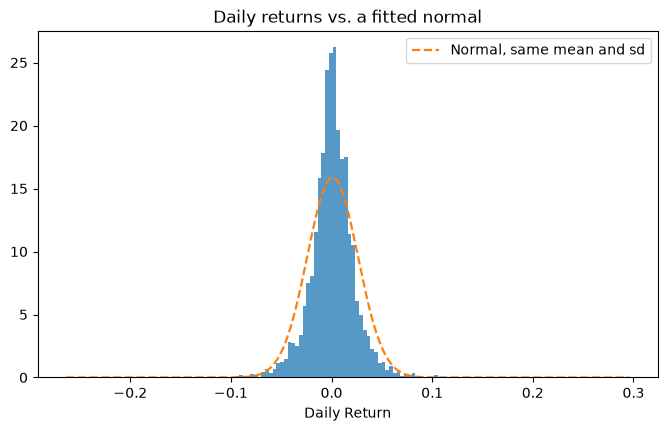

In [4]:
mu, sd = r.mean(), r.std()
print(f"mean daily {mu:.5f}")
print(f"std daily {sd:.5f}")
print(f"skew {stats.skew(r):.3f}")
print(f"excess kurt {stats.kurtosis(r):.3f}")  # 0 = normal
print(stats.jarque_bera(r))  # bigger = less normal

# Figure 2 - Historgram

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(r, bins=150, density=True, alpha=0.75)
x = np.linspace(r.min(), r.max(), 500)
ax.plot(x, stats.norm.pdf(x, mu, sd), lw=1.6, ls="--", label="Normal, same mean and sd")
ax.set_title("Daily returns vs. a fitted normal")
ax.set_xlabel("Daily Return")
ax.legend()

fig.savefig("../output/fig2_return_distribution.png", dpi=150, bbox_inches="tight")


# Exceedence Count
z = (r - mu) / sd
observed = (z.abs() > 4).sum()
expected = 2 * (1 - stats.norm.cdf(4)) * len(r)
print(f"days beyond ±4σ: observed {observed}, normal predicts {expected:.2f}")


### The Story Behind the Distribution: 
1. **Too many quiet days, far too many wild ones.** The histogram towers over the fitted normal at the centre and escapes it entirely in the tails: most days cluster tightly near zero, while the sample contains 23 days beyond ±4 standard deviations - a normal distribution predicts 0.23 in a sample this size (3,584 days), a 100x exceedance. Excess kurtosis of 19.3 (normal = 0) says the same thing numerically: the distribution is strongly **leptokurtic** - heavy-tailed, with far more probability mass in extreme outcomes than a Gaussian allows.

2. **The skew surprise** We expected a negative skew - equities typically crash harder than they rally, and META's -26% (Feb 2022) and -19% (Jul 2018) days fit this pattern. Instead skew is **+0.41**: Meta's post-earnings *surges* (+30% in Jul, +23% in Feb 2023, +21% in Feb 2024) have been as extreme as its collapses. The violence runs in both directions.

3. **Formally:** Jarque-Bera = 55,731 (p=0) rejects normality - though at n = 3,584 this is unsurprising for any real return series; the moments and exceedance count carry the substance.

Daily returns are strongly leptokurtic; the Gaussian, which mandates zero excess kurtosis, is structurally incapable of describing them — and the failure is worst in the tails, which is where risk management actually happens.

### Figure 3: Volatility and Why √252

annualized vol 39.85%
0.07025303545175354
2017-04-13 00:00:00
0.9656266376024215
2022-12-06 00:00:00


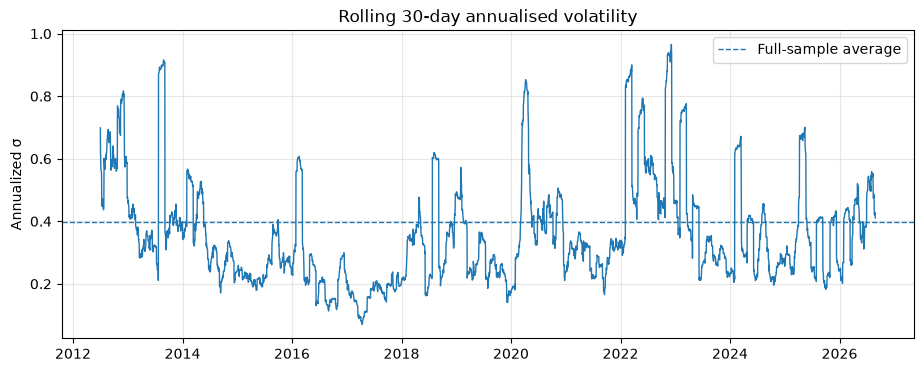

In [5]:
ann_vol = r.std() * np.sqrt(252)
print(f"annualized vol {ann_vol:.2%}")

roll = r.rolling(30).std() * np.sqrt(252)
# Test
roll_short = r.rolling(10).std() * np.sqrt(252)
roll_long = r.rolling(250).std() * np.sqrt(252)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(roll.index, roll.values, lw=1)
# ax.plot(roll_short.index, roll_short.values, lw=0.5)
# ax.plot(roll_long.index, roll_long.values, lw=0.5)
ax.axhline(ann_vol, ls="--", lw=1, label="Full-sample average")
ax.set_title("Rolling 30-day annualised volatility")
ax.set_ylabel("Annualized σ")
ax.legend()
ax.grid(alpha=0.3)

fig.savefig("../output/fig3_rolling_volatility.png", dpi=150, bbox_inches="tight")


print(roll.min())
print(roll.idxmin())
print(roll.max())
print(roll.idxmax())


In [6]:
spy = yf.download("SPY", start="2012-05-18", auto_adjust=True, progress=False)
if isinstance(spy.columns, pd.MultiIndex):
    spy.columns = spy.columns.get_level_values(0)
spy_vol = spy["Close"].pct_change().std() * np.sqrt(252)
print(f"SPY annualised vol, same window: {spy_vol:.2%}")

SPY annualised vol, same window: 16.66%


### The Story behind the volatility 

1. **One number, fourteen years, almost no overlap.** Full-sample annualised volatility is 39.9% — high even by single-stock standards large-cap names typically run ~25–35%; the S&P 500 index, where individual shocks partly cancel through diversification, ~15–20% (16.7% during the same timeframe.). But the rolling 30-day estimate ranged from **7%** (window ending Apr 2017) — briefly calmer than the index itself — to **97%** (window ending Dec 2022), wilder than the index in all but its worst crisis weeks. A 14× spread: the "average" describes almost no actual period.

2. **Volatility Clusters.** If daily returns were independent - the assumption behind the √252 annualisation - the rolling line would wander randomly around its average. Instead it shows regimes: long quiet plateaus (2016-2017), then eruptions that persist for months. Calm follows calm; storms follow storms. This is the most robust empirical regularity in asset returns, and it is why GARCH-family models exist.

3. **The peak wasn't the crash - it was the turn.** The stormiest window ends 6 Dec 2022, spanning the November trough - not the February collapse that started the decline. The mechanism: volatility measures day-to-day disagreement, not bad news. February was one enormous repricing inside an otherwise orderly window; late October-November was capitulation - the Oct 27 earnings collapse (-24.6%), forced and despairing selling into the Nov 4 bottom, then the first violent recovery rallies as exhausted supply met returning buyers. Many large moves in both directions out-storm one giant move in one direction. Turning points, where uncertainty about *direction* is maximal, are where variance peaks - declines merely trend.

4. **Estimator honesty.** Single-day shocks (Feb 2022's -26%) inflate the 30-day window for exactly 30 trading days and then fall out of it - the near-rectangular plateaus after each famous crash are an artifact of the window, not a property of the market. Window length (here 30 days) trades noise against responsiveness; the regime pattern survives any reasonable choice.

### Figure 4: Maximum Drawdown 

maximum drawdown -76.74% on 2022-11-03
peak       2021-09-07
trough     2022-11-03
recovered  2024-01-19
Days below prior peak: 93.1%
days more than 10% below: 48.2%
days more than 25% below: 18.2%


np.float64(-0.34592126682704627)

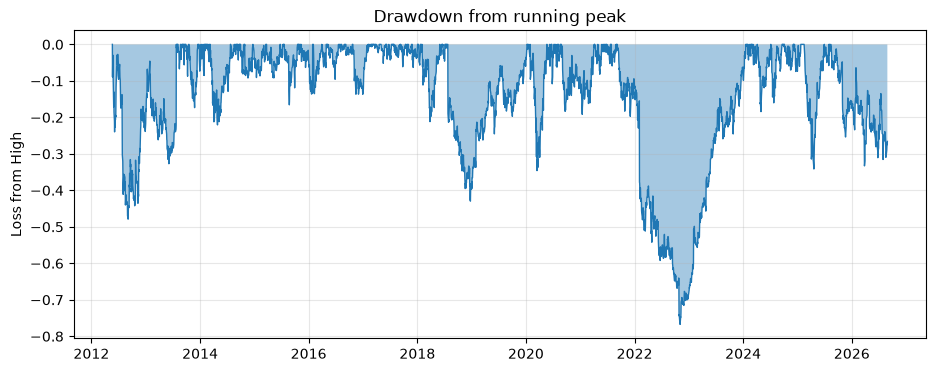

In [7]:
peak = tri.cummax()
drawdown = tri/peak - 1 # my wealth today, as a fraction of the best its ever been, minus one.

print(f"maximum drawdown {drawdown.min():.2%} on {drawdown.idxmin().date()}")

fig, ax = plt.subplots(figsize=(11,4))
ax.fill_between(drawdown.index, drawdown.values, 0, alpha=0.4)
ax.plot(drawdown.index, drawdown.values, lw=1)
ax.set_title("Drawdown from running peak")
ax.set_ylabel('Loss from High'); ax.grid(alpha=0.3)

fig.savefig("../output/fig4_drawdown.png", dpi=150, bbox_inches="tight")

trough = drawdown.idxmin()
prior_pk = tri[:trough].idxmax()
recovery = drawdown[trough:][drawdown[trough:] >= 0]
recovered = recovery.index[0] if len(recovery) else None

print('peak      ', prior_pk.date())
print('trough    ', trough.date())
print('recovered ', recovered.date() if recovered is not None else 'not yet')
(r[prior_pk:trough] > 0).mean()
(drawdown < 0).mean()
1/(1 +drawdown.min()) - 1

w_peak = tri[prior_pk]
w_trough = tri[trough]

(w_peak - w_trough)/w_trough #percentage back to the top

# Point 3: Drawdown as the Normal State
print(f"Days below prior peak: {(drawdown < 0).mean():.1%}")
print(f"days more than 10% below: {(drawdown < -0.1).mean():.1%}")
print(f"days more than 25% below: {(drawdown < -0.25).mean():.1%}")
drawdown.loc["2018":"2019"].min()
drawdown.loc["2020"].min()
# Point 4: The Behavioural Close

### Story of META's Drawdown  

1. **Depth and Duration, together.** From the peak of 7 September 2021, META declined for 422 days to its trough on 3 November 2022 - a maximum drawdown of **-76.74%**. The fall was a trend, not a streak: roughly 46.6% of the days in the decline were positive, but down days dominated. Recovery to the prior peak took another 442 days (19 January 2024), for a total underwater period of 864 days - **2.4 years** during which a peak buyer was losing money. The entire episode coincides with the elevated-volatility regime visible in Fig 3: the decline happened inside the storm, not alongside it.

2. **The Asymmetry.** The climb back took longer than the fall - 442 days to recover versus 422 to decline. The reason is arithmetic: from a -76.74% loss, break-even to the previous peak requires a gain of **+329.85%**. A 77% loss does not need a 77% gain, because the two percentages are measured off different bases - the loss of the peak, the required gain off the trough. In wealth terms: the fall from 10.0x to 2.3x is -77% of the large number; the climb from 2.3x back to 10.0x is 330% of the smaller one. Same distance, different denominators - which is why deep drawdowns take years, not months, to heal.

3. **Underwater is the normal state.** The 2022 episode dominates the chart, but it is not an anomaly in kind - only in degree. Across the full sample, META closed below a prior peak on 93.1% of all trading days, more than 10% below on 48.2%, and more than 25% below on 18.1%. The chart touches zero only at new highs, and the record shows repeated major episodes: the post-IPO collapse (-53%, underwater until mid-2013), 2018 (-43%), COVID 2020 (-34.6%), and 2021-2024 (-76.74%). A stock that multiplied wealth 14.5x spent the large majority of its life below some prior high - new records are brief punctuation, not the resting state. Anyone holding a growth stock should expect to feel behind most of the time, even while winning.

4. **Risk as Experienced.** Volatility (Fig 3) is risk as models measure it; drawdown is risk as investors live it. A peak buyer endured 422 days of decline, a -26.4% single day five months in, no way to distinguish the several false bottoms before it, and a paper loss of -76.74% - while consensus held that the company was finished. Most investors sell somewhere in that sequence, and selling converts a temporary drawdown into a permanent loss: the +330% recovery accrued only those still holding in January 2024. This is why performance figures reported without drawdowns are incomplete - a return stream is only as good as an investor's ability to survive its worst stretch. One caution: this chart rewards holding only in hindsight. META recovered; many stocks with identical-looking charts did not. The lesson is not "never sell" - it is that drawdown depth and duration are the risk numbers to know *before* buying, because no one reasons well at -60%.

## Summary

The four figures above answer the opening question in one direction: Meta's daily returns depart from the introductory normal-distribution model in every moment that carries risk.

Meta's daily returns (2012–2026) are strongly leptokurtic: excess kurtosis of 19.3 against a Gaussian benchmark of zero, with 23 days beyond ±4σ where a normal distribution predicts 0.23 — a 100× exceedance. Skew is +0.41, against the typical negative skew of equities, driven by post-earnings surges as violent as the crashes. Annualised volatility averaged 39.9% — 2.4× the S&P 500's 16.7% over the same window — but ranged from 7% to 97% across rolling 30-day windows: volatility arrives in persistent regimes, not as a constant. The worst drawdown reached −76.74% (Sep 2021 → Nov 2022, 422 days), took a further 442 days to recover, and left a peak buyer underwater for 2.4 years — recovery required a +330% gain, the asymmetry that makes deep drawdowns slow to heal. One limitation stated plainly: the volatility regimes of Fig 3 and the drawdown of Fig 4 visibly coincide but measure different things — vol tracks the intensity of fluctuation regardless of direction, drawdown tracks sustained direction — and this analysis establishes their coincidence, not a formal link.

## References

**Data:** Yahoo Finance daily prices, retrieved via the `yfinance` Python package
(auto_adjust=True). All return, volatility, and drawdown figures are computed
in this notebook from that data.

**Narrative sources:**
1. CNBC — "Facebook's $232 billion fall sets record for largest one-day value
   drop in stock market history" (Feb 3, 2022).
   https://www.cnbc.com/2022/02/03/facebooks-232billion-drop-in-value-sets-all-time-record.html
2. CNBC — "Nvidia sheds almost $600 billion in market cap, biggest one-day loss
   in U.S. history" (Jan 27, 2025).
   https://www.cnbc.com/2025/01/27/nvidia-sheds-almost-600-billion-in-market-cap-biggest-drop-ever.html
3. Bloomberg — "Facebook's $119 Billion One-Day Rout Makes U.S. History"
   (Jul 26, 2018).
   https://www.bloomberg.com/news/articles/2018-07-26/facebook-s-119-billion-one-day-rout-makes-u-s-history-chart
4. CNBC — "Facebook's IPO 10 years later" (May 18, 2022) — post-IPO decline of
   roughly half within three months.
   https://www.cnbc.com/2022/05/18/facebook-ipo-10-years-later-new-name-same-ceo-familiar-problem.html
5. Krigman & Jeffus, "IPO pricing as a function of your investment banks' past
   mistakes: The case of Facebook," *Journal of Corporate Finance* (2016) —
   IPO mechanics; $17.73 close on Sep 4, 2012.
   https://www.sciencedirect.com/science/article/abs/pii/S0929119916300190